# Simple Linear Regression

## 1. Introduction to Linear Regression
Linear Regression is the most fundamental algorithm in Machine Learning. It is a **Supervised Machine Learning** algorithm specifically used for **Regression tasks** (i.e., when the target output variable is a continuous numerical value, like predicting salary, temperature, or price).

There are primarily three types of Linear Regression:
1. **Simple Linear Regression:** 1 Input Column (Feature) and 1 Output Column (Target).
2. **Multiple Linear Regression:** Multiple Input Columns (Features) and 1 Output Column.
3. **Polynomial Linear Regression:** Used when the data has a non-linear relationship.

## 2. The Geometric Intuition
Imagine plotting a dataset of students on a 2D graph where the X-axis is `CGPA` and the Y-axis is `Placement Package`. 

### Why is real-world data never perfectly linear?
If the data were perfectly linear, all points would fall exactly on a straight line. However, real-world data is usually just "sort of linear" (a scattered linear trend). This happens because of hidden variables (e.g., a student with a low CGPA might have great communication skills and get a high package, which our 2D data cannot capture).

### The "Best Fit Line"
Since the points are scattered, Simple Linear Regression calculates the **Best Fit Line**. 
* **Definition:** A straight line drawn through the center of the data points that makes the *minimum amount of overall error* (the distance from the actual points to the line is as small as possible).
* Once this line is discovered, the algorithm uses it to predict the future output for any new input.

## 3. The Mathematical & Human Intuition
The equation of a straight line in mathematics is:
$$y = mx + b$$

In the context of Machine Learning (predicting Package based on CGPA):
$$Package = m \times (CGPA) + b$$

What do $m$ and $b$ actually represent in human terms?

### The Slope ($m$): The "Weightage"
* Mathematically, $m$ is the slope of the line. 
* Intuitively, $m$ represents the **Weightage** or **Importance** of the input feature. 
* If $m$ is a large number, it means your Package heavily depends on your CGPA (a small increase in CGPA leads to a massive jump in Package). If $m$ is small, CGPA has very little impact on the final Package.

### The Y-Intercept ($b$): The "Offset" or "Base Value"
* Mathematically, $b$ is the point where the line crosses the Y-axis (when $x = 0$).
* Intuitively, $b$ is the **Offset** or base expectation. 
* *Example:* If we were predicting Salary based on Years of Experience ($Salary = m \times Experience + b$), what happens if a fresh graduate applies (Experience = 0)? If $b$ didn't exist, their salary would mathematically be 0! The intercept $b$ acts as the base starting salary that everyone gets regardless of experience.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


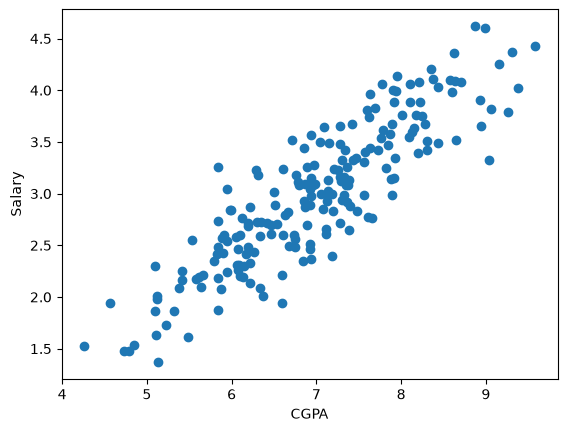

In [7]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Salary')
plt.show()

In [9]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [13]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.57]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.027
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [16]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy = lr.score(X_test, y_test)

In [20]:
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 77.31%
